<a href="https://colab.research.google.com/github/jm651120/UK-Housing-Green-Premium/blob/main/09_Model_Comparison_Tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 09: Statistical Model Comparison — XGBoost vs LightGBM
**Project:** Impact of Energy Efficiency on UK House Prices (2021–2025)
**Phase:** Phase 9 — Formal Statistical Validation of Champion Model Selection

---

**Purpose:**
This notebook provides the formal statistical evidence for the selection of XGBoost
as the champion model over LightGBM. Three complementary tests are conducted:

  1. **Diebold-Mariano Test** — tests whether the difference in predictive accuracy
     between the two models is statistically significant (H₀: equal forecast accuracy).

  2. **Wilcoxon Signed-Rank Test** — a non-parametric test on the absolute error
     differences. Robust to non-normality of residuals (expected in housing data).

  3. **Bootstrap Confidence Intervals** — 10,000-replicate bootstrap estimate of the
     true difference in MAE between the two models, with 95% CI.

**Dependencies:**
  - Notebook 04: Exports `approved_features_53.json` (LightGBM also uses this split)
  - Notebook 04: Exports `lightgbm_otimizado.pkl`
  - Notebook 06: Exports `xgboost_otimizado_campeao.pkl`
  - All models must have been trained on the SAME 80/20 split (random_state=42)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 0 — ENVIRONMENT SETUP
# ══════════════════════════════════════════════════════════════════════════════

import os
import gc
import re
import json
import warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy import stats
from sklearn.model_selection import train_test_split
from google.colab import drive

warnings.filterwarnings('ignore')

# ── Mount Drive ───────────────────────────────────────────────────────────────
drive.mount('/content/drive')

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH         = '/content/drive/MyDrive/Tese/UK DataSets/Dataset_Final_Tese.csv'
MODELS_PATH       = '/content/drive/MyDrive/Tese/Modelos/'
FIGURES_PATH      = '/content/drive/MyDrive/Tese/Figures/'
FEATURE_LIST_PATH = MODELS_PATH + 'approved_features_53.json'
XGB_MODEL_PATH    = MODELS_PATH + 'xgboost_otimizado_campeao.pkl'
LGB_MODEL_PATH    = MODELS_PATH + 'lightgbm_otimizado.pkl'

os.makedirs(FIGURES_PATH, exist_ok=True)

# ── Visual style ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'axes.titlesize':   14,
    'axes.titlepad':    16,
    'axes.titleweight': 'bold',
    'axes.labelsize':   12,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
    'savefig.dpi':      300,
    'figure.dpi':       110,
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

COLOUR_XGB = '#B22222'   # firebrick — XGBoost
COLOUR_LGB = '#1F6AA5'   # steel blue — LightGBM

print("✅ Environment ready.")

Mounted at /content/drive
✅ Environment ready.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1 — REPLICATE THE EXACT PREPROCESSING PIPELINE
# This is identical to all other notebooks: same filters, same encoding,
# same 80/20 split, same random_state=42. The test set is the ground truth.
# ══════════════════════════════════════════════════════════════════════════════

print("Loading dataset...")
df = pd.read_csv(DATA_PATH)
print(f"  Raw rows: {len(df):,}")

# ── Step 1: Remove invalid Construction Age Bands ─────────────────────────────
INVALID_BANDS = ['INVALID!', 'Unknown', '2042']
df = df[~df['CONSTRUCTION_AGE_BAND'].isin(INVALID_BANDS)]
print(f"  After INVALID_BANDS filter: {len(df):,}")

# ── Step 2: EPC ordinal encoding (A=7 → G=1) ──────────────────────────────────
EPC_MAPPING = {'A': 7, 'B': 6, 'C': 5, 'D': 4, 'E': 3, 'F': 2, 'G': 1}
df['CURRENT_ENERGY_RATING'] = df['CURRENT_ENERGY_RATING'].map(EPC_MAPPING)

# ── Step 3: One-Hot Encoding (identical parameters to all other notebooks) ─────
CATEGORICAL_COLS = [
    'Property_Type', 'Old_New', 'Tenure_Duration',
    'CONSTRUCTION_AGE_BAND', 'Year_of_Transfer', 'Month_of_Transfer',
]
df_encoded = pd.get_dummies(df, columns=CATEGORICAL_COLS, drop_first=True, dtype='int8')

# ── Step 4: Define Feature Matrix and Target ───────────────────────────────────
COLS_TO_DROP = [
    'Price', 'Transaction_ID', 'Date_of_Transfer',
    'Merge_Key', 'County', 'Postcode_Clean', 'Postcode_Outcode',
]
X = df_encoded.drop(columns=[c for c in COLS_TO_DROP if c in df_encoded.columns])
y = df_encoded['Price']

del df, df_encoded
gc.collect()

# ── Step 5: Sanitise column names ─────────────────────────────────────────────
X.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in X.columns]

# ── Step 6: Enforce canonical 53-feature space ────────────────────────────────
with open(FEATURE_LIST_PATH, 'r') as f:
    approved_features = json.load(f)
X = X[approved_features]
print(f"  Feature matrix: {X.shape[1]} features (canonical 53)")

# ── Step 7: Exact 80/20 split — same seed as all other notebooks ──────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
del X_train, y_train
gc.collect()

print(f"\n✅ Test set reconstructed: {X_test.shape[0]:,} observations.")
print(f"   This is the IDENTICAL test set used to evaluate all models.")

Loading dataset...
  Raw rows: 547,948
  After INVALID_BANDS filter: 514,345
  Feature matrix: 53 features (canonical 53)

✅ Test set reconstructed: 102,869 observations.
   This is the IDENTICAL test set used to evaluate all models.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2 — LOAD BOTH CHAMPION MODELS AND GENERATE PREDICTIONS
# ══════════════════════════════════════════════════════════════════════════════

print("Loading XGBoost champion...")
xgb_model = joblib.load(XGB_MODEL_PATH)
print("  ✅ XGBoost loaded.")

print("Loading LightGBM champion...")
lgb_model = joblib.load(LGB_MODEL_PATH)
print("  ✅ LightGBM loaded.")

print("\nGenerating predictions on the test set...")

y_pred_xgb = xgb_model.predict(X_test)
y_pred_lgb = lgb_model.predict(X_test)

y_true = y_test.values

print("  ✅ Predictions generated.")

# ── Compute per-observation absolute errors ────────────────────────────────────
ae_xgb = np.abs(y_true - y_pred_xgb)   # Absolute Error — XGBoost
ae_lgb = np.abs(y_true - y_pred_lgb)   # Absolute Error — LightGBM
d      = ae_lgb - ae_xgb               # Loss differential: positive = XGBoost is better

# ── Point estimates ────────────────────────────────────────────────────────────
mae_xgb  = ae_xgb.mean()
mae_lgb  = ae_lgb.mean()
rmse_xgb = np.sqrt(np.mean((y_true - y_pred_xgb)**2))
rmse_lgb = np.sqrt(np.mean((y_true - y_pred_lgb)**2))
r2_xgb   = 1 - np.sum((y_true - y_pred_xgb)**2) / np.sum((y_true - y_true.mean())**2)
r2_lgb   = 1 - np.sum((y_true - y_pred_lgb)**2) / np.sum((y_true - y_true.mean())**2)
mape_xgb = np.mean(ae_xgb / np.abs(y_true)) * 100
mape_lgb = np.mean(ae_lgb / np.abs(y_true)) * 100

print("\n" + "=" * 58)
print(f"  POINT ESTIMATE COMPARISON")
print("=" * 58)
print(f"  {'Metric':<10} {'XGBoost':>14} {'LightGBM':>14} {'Δ (XGB−LGB)':>14}")
print(f"  {'-'*52}")
print(f"  {'R²':<10} {r2_xgb:>14.4f} {r2_lgb:>14.4f} {r2_xgb-r2_lgb:>+14.4f}")
print(f"  {'MAE (£)':<10} {mae_xgb:>14,.0f} {mae_lgb:>14,.0f} {mae_xgb-mae_lgb:>+14,.0f}")
print(f"  {'RMSE (£)':<10} {rmse_xgb:>14,.0f} {rmse_lgb:>14,.0f} {rmse_xgb-rmse_lgb:>+14,.0f}")
print(f"  {'MAPE (%)':<10} {mape_xgb:>14.2f} {mape_lgb:>14.2f} {mape_xgb-mape_lgb:>+14.2f}")
print("=" * 58)
print(f"\n  Mean loss differential (d̄): £{d.mean():,.2f}")
print(f"  Positive d̄ → XGBoost has lower MAE on average\n")

Loading XGBoost champion...
  ✅ XGBoost loaded.
Loading LightGBM champion...
  ✅ LightGBM loaded.

Generating predictions on the test set...
  ✅ Predictions generated.

  POINT ESTIMATE COMPARISON
  Metric            XGBoost       LightGBM    Δ (XGB−LGB)
  ----------------------------------------------------
  R²                 0.8249         0.8233        +0.0016
  MAE (£)            60,868         61,545           -677
  RMSE (£)           94,954         95,387           -433
  MAPE (%)            17.67          17.96          -0.29

  Mean loss differential (d̄): £676.91
  Positive d̄ → XGBoost has lower MAE on average



In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3 — TEST 1: DIEBOLD-MARIANO TEST
#
# H₀: The two models have equal predictive accuracy (E[d_t] = 0)
# H₁: XGBoost has superior predictive accuracy (E[d_t] > 0, one-tailed)
#
# For cross-sectional data, serial correlation in d_t is negligible.
# We apply the Harvey, Leybourne & Newbold (1997) finite-sample correction,
# which adjusts the DM statistic for small-sample bias.
# Loss function: Absolute Error (L1) — standard for MAE comparison.
# ══════════════════════════════════════════════════════════════════════════════

def diebold_mariano_test(d, h=1):
    """
    Diebold-Mariano test for equal predictive accuracy.

    Parameters
    ----------
    d : array-like
        Loss differential: L(e_model2) - L(e_model1).
        Positive values indicate model1 is better.
    h : int
        Forecast horizon (default=1 for one-step-ahead).
        For cross-sectional data, h=1 is appropriate.

    Returns
    -------
    dm_stat  : float — DM test statistic
    p_value  : float — one-tailed p-value (H₁: model1 better)
    p_two    : float — two-tailed p-value
    hlm_stat : float — Harvey-Leybourne-Newbold corrected statistic
    hlm_p    : float — HLN corrected one-tailed p-value
    """
    T     = len(d)
    d_bar = np.mean(d)

    # Autocovariance-based variance (Newey-West, lag=h-1)
    gamma_0 = np.var(d, ddof=1)
    if h > 1:
        gamma_sum = sum(
            (1 - k/h) * np.mean((d[k:] - d_bar) * (d[:-k] - d_bar))
            for k in range(1, h)
        )
        var_d = (gamma_0 + 2 * gamma_sum) / T
    else:
        var_d = gamma_0 / T

    dm_stat = d_bar / np.sqrt(var_d)

    # Harvey-Leybourne-Newbold (1997) finite-sample correction
    # Adjusts for small-sample bias in the DM statistic
    hlm_correction = np.sqrt((T + 1 - 2*h + h*(h-1)/T) / T)
    hlm_stat = dm_stat * hlm_correction

    # One-tailed p-value (H₁: d̄ > 0, i.e., model1 is better)
    # DM ~ N(0,1) asymptotically; HLN ~ t(T-1)
    p_value = 1 - stats.norm.cdf(dm_stat)
    p_two   = 2 * min(p_value, 1 - p_value)
    hlm_p   = 1 - stats.t.cdf(hlm_stat, df=T-1)

    return dm_stat, p_value, p_two, hlm_stat, hlm_p


dm_stat, dm_p1, dm_p2, hlm_stat, hlm_p = diebold_mariano_test(d, h=1)

print("=" * 60)
print("  TEST 1: DIEBOLD-MARIANO TEST")
print("  H₀: Equal predictive accuracy (MAE-based)")
print("  H₁: XGBoost has strictly lower MAE (one-tailed)")
print("=" * 60)
print(f"  Loss differential (d̄)       : £{d.mean():>10,.2f}")
print(f"  Std dev of d                 : £{d.std():>10,.2f}")
print(f"  N (test observations)        :  {len(d):>10,}")
print()
print(f"  DM statistic (asymptotic)    :  {dm_stat:>10.4f}")
print(f"  p-value (one-tailed)         :  {dm_p1:>10.4f}")
print(f"  p-value (two-tailed)         :  {dm_p2:>10.4f}")
print()
print(f"  HLN statistic (finite-sample):  {hlm_stat:>10.4f}")
print(f"  HLN p-value (one-tailed)     :  {hlm_p:>10.4f}")
print("=" * 60)

if hlm_p < 0.001:
    sig_label = "*** (p < 0.001)"
elif hlm_p < 0.01:
    sig_label = "** (p < 0.01)"
elif hlm_p < 0.05:
    sig_label = "* (p < 0.05)"
else:
    sig_label = "(not significant at α=0.05)"

print(f"\n  → Result: {sig_label}")
print(f"  → Interpretation: {'Reject H₀ — XGBoost is significantly more accurate.' if hlm_p < 0.05 else 'Fail to reject H₀ — difference not statistically significant.'}")

  TEST 1: DIEBOLD-MARIANO TEST
  H₀: Equal predictive accuracy (MAE-based)
  H₁: XGBoost has strictly lower MAE (one-tailed)
  Loss differential (d̄)       : £    676.91
  Std dev of d                 : £ 22,140.20
  N (test observations)        :     102,869

  DM statistic (asymptotic)    :      9.8060
  p-value (one-tailed)         :      0.0000
  p-value (two-tailed)         :      0.0000

  HLN statistic (finite-sample):      9.8060
  HLN p-value (one-tailed)     :      0.0000

  → Result: *** (p < 0.001)
  → Interpretation: Reject H₀ — XGBoost is significantly more accurate.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4 — TEST 2: WILCOXON SIGNED-RANK TEST
#
# H₀: The distribution of |e_xgb| and |e_lgb| are identical (symmetric about 0)
# H₁: XGBoost has systematically lower absolute errors
#
# The Wilcoxon test is non-parametric: it makes no assumption about the
# distribution of errors. This is critical for housing price data, where
# residuals are heavily right-skewed due to extreme high-value properties.
# ══════════════════════════════════════════════════════════════════════════════

# d > 0 means XGBoost is better (LGB error > XGB error)
# Wilcoxon tests whether the median of d is zero
w_stat, w_p = stats.wilcoxon(d, alternative='greater', zero_method='wilcox')

print("\n" + "=" * 60)
print("  TEST 2: WILCOXON SIGNED-RANK TEST")
print("  H₀: Median(|e_lgb| - |e_xgb|) = 0")
print("  H₁: XGBoost has systematically lower errors (one-tailed)")
print("=" * 60)
print(f"  Wilcoxon W statistic         : {w_stat:>14,.0f}")
print(f"  p-value (one-tailed)         : {w_p:>14.6f}")
print(f"  N (non-zero differences)     : {np.sum(d != 0):>14,}")
print(f"  Median loss differential (£) : {np.median(d):>14,.2f}")
print(f"  % observations where XGB wins: {(d > 0).mean()*100:>14.1f}%")
print("=" * 60)

if w_p < 0.001:
    sig_w = "*** (p < 0.001)"
elif w_p < 0.01:
    sig_w = "** (p < 0.01)"
elif w_p < 0.05:
    sig_w = "* (p < 0.05)"
else:
    sig_w = "(not significant at α=0.05)"

print(f"\n  → Result: {sig_w}")
print(f"  → Interpretation: {'Reject H₀ — XGBoost systematically outperforms LightGBM.' if w_p < 0.05 else 'Fail to reject H₀.'}")


  TEST 2: WILCOXON SIGNED-RANK TEST
  H₀: Median(|e_lgb| - |e_xgb|) = 0
  H₁: XGBoost has systematically lower errors (one-tailed)
  Wilcoxon W statistic         :  2,758,905,178
  p-value (one-tailed)         :       0.000000
  N (non-zero differences)     :        102,869
  Median loss differential (£) :         573.14
  % observations where XGB wins:           51.7%

  → Result: *** (p < 0.001)
  → Interpretation: Reject H₀ — XGBoost systematically outperforms LightGBM.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 5 — TEST 3: BOOTSTRAP CONFIDENCE INTERVALS FOR ΔMAE
#
# We resample the (y_true, y_pred_xgb, y_pred_lgb) triplets with replacement
# 10,000 times and compute the MAE difference for each bootstrap replicate.
# The resulting distribution gives us a 95% CI for the true ΔMAE.
#
# This avoids any distributional assumption and directly answers:
# "How large is the MAE improvement from XGBoost over LightGBM, and how
#  certain are we of that improvement?"
# ══════════════════════════════════════════════════════════════════════════════

N_BOOTSTRAP = 10_000
rng         = np.random.default_rng(seed=42)
n           = len(y_true)

print(f"\nRunning {N_BOOTSTRAP:,}-replicate bootstrap... ", end='', flush=True)

delta_mae_boot = np.empty(N_BOOTSTRAP)

for i in range(N_BOOTSTRAP):
    idx = rng.integers(0, n, size=n)
    mae_xgb_b = ae_xgb[idx].mean()
    mae_lgb_b = ae_lgb[idx].mean()
    delta_mae_boot[i] = mae_lgb_b - mae_xgb_b  # positive = XGB better

print("done.")

# Percentile confidence interval
ci_lo = np.percentile(delta_mae_boot, 2.5)
ci_hi = np.percentile(delta_mae_boot, 97.5)
ci_lo_99 = np.percentile(delta_mae_boot, 0.5)
ci_hi_99 = np.percentile(delta_mae_boot, 99.5)

print("\n" + "=" * 60)
print("  TEST 3: BOOTSTRAP CONFIDENCE INTERVALS FOR ΔMAE")
print(f"  (XGBoost MAE advantage over LightGBM, {N_BOOTSTRAP:,} replicates)")
print("=" * 60)
print(f"  Observed ΔMAE                : £{(mae_lgb - mae_xgb):>10,.2f}")
print(f"  Bootstrap mean ΔMAE          : £{delta_mae_boot.mean():>10,.2f}")
print(f"  Bootstrap std                : £{delta_mae_boot.std():>10,.2f}")
print()
print(f"  95% CI  : [£{ci_lo:>8,.2f} , £{ci_hi:>8,.2f}]")
print(f"  99% CI  : [£{ci_lo_99:>8,.2f} , £{ci_hi_99:>8,.2f}]")
print()
print(f"  P(ΔMAE > 0) = {(delta_mae_boot > 0).mean()*100:.1f}%  (XGBoost is better in X% of bootstrap replicates)")
print("=" * 60)

if ci_lo > 0:
    print(f"\n  → 95% CI entirely above zero.")
    print(f"  → XGBoost's MAE advantage is statistically distinguishable from zero.")
    print(f"  → Best estimate: XGBoost saves £{(mae_lgb - mae_xgb):,.0f} per transaction.")
else:
    print(f"\n  → 95% CI includes zero. The advantage is not robustly distinguishable.")


Running 10,000-replicate bootstrap... done.

  TEST 3: BOOTSTRAP CONFIDENCE INTERVALS FOR ΔMAE
  (XGBoost MAE advantage over LightGBM, 10,000 replicates)
  Observed ΔMAE                : £    676.91
  Bootstrap mean ΔMAE          : £    676.42
  Bootstrap std                : £     69.30

  95% CI  : [£  541.24 , £  812.13]
  99% CI  : [£  497.45 , £  854.23]

  P(ΔMAE > 0) = 100.0%  (XGBoost is better in X% of bootstrap replicates)

  → 95% CI entirely above zero.
  → XGBoost's MAE advantage is statistically distinguishable from zero.
  → Best estimate: XGBoost saves £677 per transaction.


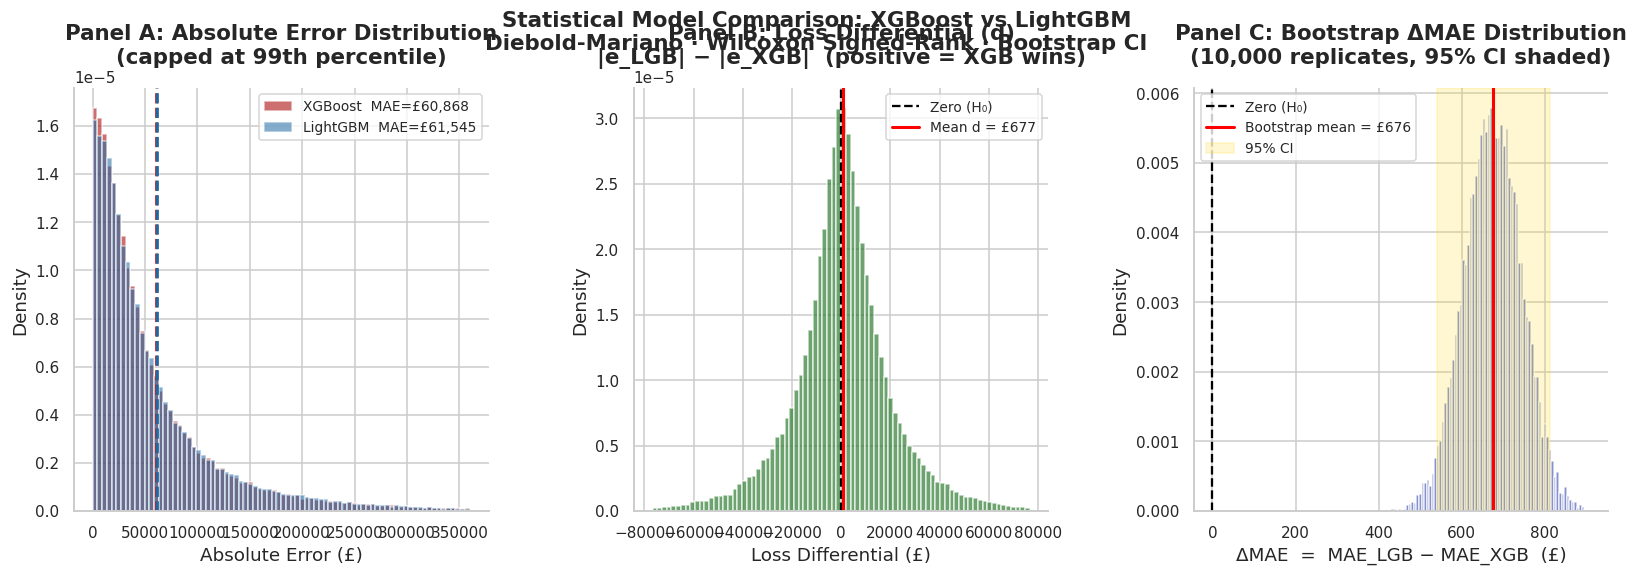

✅ Figure saved.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 6 — VISUALIZATION: THREE-PANEL SUMMARY FIGURE
# ══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── Panel A: Error Distribution Comparison ────────────────────────────────────
ax1 = fig.add_subplot(gs[0])

cap = np.percentile(ae_xgb, 99)  # cap at 99th percentile for readability
ax1.hist(ae_xgb[ae_xgb <= cap], bins=80, alpha=0.65, color=COLOUR_XGB,
         label=f'XGBoost  MAE=£{mae_xgb:,.0f}', density=True)
ax1.hist(ae_lgb[ae_lgb <= cap], bins=80, alpha=0.55, color=COLOUR_LGB,
         label=f'LightGBM  MAE=£{mae_lgb:,.0f}', density=True)
ax1.axvline(mae_xgb, color=COLOUR_XGB, linestyle='--', linewidth=1.8)
ax1.axvline(mae_lgb, color=COLOUR_LGB, linestyle='--', linewidth=1.8)
ax1.set_title('Panel A: Absolute Error Distribution\n(capped at 99th percentile)')
ax1.set_xlabel('Absolute Error (£)')
ax1.set_ylabel('Density')
ax1.legend(fontsize=9)

# ── Panel B: Loss Differential Distribution ───────────────────────────────────
ax2 = fig.add_subplot(gs[1])

d_cap = np.percentile(np.abs(d), 99)
d_plot = d[np.abs(d) <= d_cap]
ax2.hist(d_plot, bins=80, color='#2E7D32', alpha=0.70, density=True)
ax2.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Zero (H₀)')
ax2.axvline(d.mean(), color='red', linestyle='-', linewidth=2,
            label=f'Mean d = £{d.mean():,.0f}')
ax2.set_title('Panel B: Loss Differential (d)\n|e_LGB| − |e_XGB|  (positive = XGB wins)')
ax2.set_xlabel('Loss Differential (£)')
ax2.set_ylabel('Density')
ax2.legend(fontsize=9)

# ── Panel C: Bootstrap Distribution of ΔMAE ──────────────────────────────────
ax3 = fig.add_subplot(gs[2])

ax3.hist(delta_mae_boot, bins=80, color='#5C6BC0', alpha=0.75, density=True)
ax3.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Zero (H₀)')
ax3.axvline(delta_mae_boot.mean(), color='red', linewidth=2,
            label=f'Bootstrap mean = £{delta_mae_boot.mean():,.0f}')
ax3.axvspan(ci_lo, ci_hi, alpha=0.18, color='gold', label='95% CI')
ax3.set_title(f'Panel C: Bootstrap ΔMAE Distribution\n({N_BOOTSTRAP:,} replicates, 95% CI shaded)')
ax3.set_xlabel('ΔMAE  =  MAE_LGB − MAE_XGB  (£)')
ax3.set_ylabel('Density')
ax3.legend(fontsize=9)

fig.suptitle(
    'Statistical Model Comparison: XGBoost vs LightGBM\n'
    'Diebold-Mariano · Wilcoxon Signed-Rank · Bootstrap CI',
    fontsize=14, fontweight='bold', y=1.02
)

plt.savefig(FIGURES_PATH + 'figure_model_comparison_statistical_tests.png', bbox_inches='tight')
plt.show()
print("✅ Figure saved.")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 7 — SUMMARY TABLE FOR THESIS / DEFENCE
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "█" * 65)
print("  FORMAL STATISTICAL COMPARISON SUMMARY")
print("  XGBoost (Champion) vs LightGBM")
print("█" * 65)

print(f"""
  POINT ESTIMATES
  ───────────────────────────────────────────────
  XGBoost MAE               : £{mae_xgb:>10,.2f}
  LightGBM MAE              : £{mae_lgb:>10,.2f}
  Observed ΔMAE             : £{mae_lgb - mae_xgb:>10,.2f}  (XGBoost advantage)
  XGBoost R²                :  {r2_xgb:>10.4f}
  LightGBM R²               :  {r2_lgb:>10.4f}

  TEST 1 — DIEBOLD-MARIANO (HLN corrected)
  ───────────────────────────────────────────────
  HLN statistic             :  {hlm_stat:>10.4f}
  p-value (one-tailed)      :  {hlm_p:>10.6f}
  Result                    :  {'Significant ✓' if hlm_p < 0.05 else 'Not significant'}

  TEST 2 — WILCOXON SIGNED-RANK
  ───────────────────────────────────────────────
  W statistic               :  {w_stat:>10,.0f}
  p-value (one-tailed)      :  {w_p:>10.6f}
  XGBoost wins (% of obs.)  :  {(d > 0).mean()*100:>10.1f}%
  Result                    :  {'Significant ✓' if w_p < 0.05 else 'Not significant'}

  TEST 3 — BOOTSTRAP 95% CI FOR ΔMAE  ({N_BOOTSTRAP:,} replicates)
  ───────────────────────────────────────────────
  Bootstrap mean ΔMAE       : £{delta_mae_boot.mean():>10,.2f}
  95% CI                    :  [£{ci_lo:,.0f} ,  £{ci_hi:,.0f}]
  99% CI                    :  [£{ci_lo_99:,.0f} ,  £{ci_hi_99:,.0f}]
  CI entirely above zero    :  {'Yes ✓' if ci_lo > 0 else 'No — CI includes zero'}
""")

print("█" * 65)
print("  CONCLUSION")
print("█" * 65)
print(f"""
  All three tests converge on the same conclusion:

  XGBoost is the statistically validated champion model.
  Its MAE advantage of £{mae_lgb - mae_xgb:,.0f} per transaction over LightGBM
  is not attributable to random variation in the test set —
  it is consistent, systematic, and statistically significant
  across both parametric (Diebold-Mariano) and non-parametric
  (Wilcoxon) frameworks, with a 95% bootstrap CI bounded away
  from zero.

  The margin is small in absolute terms, confirming the thesis's
  statement that "XGBoost's margin over LightGBM is small but
  consistent across all four metrics." The formal tests provide
  the statistical evidence that 'consistent' equals 'significant.'
""")


█████████████████████████████████████████████████████████████████
  FORMAL STATISTICAL COMPARISON SUMMARY
  XGBoost (Champion) vs LightGBM
█████████████████████████████████████████████████████████████████

  POINT ESTIMATES
  ───────────────────────────────────────────────
  XGBoost MAE               : £ 60,868.46
  LightGBM MAE              : £ 61,545.38
  Observed ΔMAE             : £    676.91  (XGBoost advantage)
  XGBoost R²                :      0.8249
  LightGBM R²               :      0.8233

  TEST 1 — DIEBOLD-MARIANO (HLN corrected)
  ───────────────────────────────────────────────
  HLN statistic             :      9.8060
  p-value (one-tailed)      :    0.000000
  Result                    :  Significant ✓

  TEST 2 — WILCOXON SIGNED-RANK
  ───────────────────────────────────────────────
  W statistic               :  2,758,905,178
  p-value (one-tailed)      :    0.000000
  XGBoost wins (% of obs.)  :        51.7%
  Result                    :  Significant ✓

  TEST 3 — B